# Phase 2 — Continual Learning Setup & Catastrophic Forgetting

**Paper:** Code Division Modulation Layers Against Forgetting and Inference in Continual Gait Identification  
**Reference:** Milani, S. — University of Padova

---

## What this notebook does

1. Implements the **baseline CNN** from Zou et al. (2020) as described in the paper (Fig. 2)
2. Builds the **4-task continual learning split** (Table II)
3. Trains the model **sequentially** on Tasks 1 → 2 → 3 → 4 with standard fine-tuning (no forgetting mitigation)
4. Evaluates accuracy on **all previous tasks** after each training step
5. Plots the **catastrophic forgetting curve** — the key baseline that CDML must beat

## Expected outcome

After training on Task 4, accuracy on Task 1 should drop sharply.  
This is the `Std. 0%` row from Fig. 4 of the paper — your starting point.

---

In [60]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Using device: cpu
PyTorch version: 2.8.0


## 1. Configuration

All experiment parameters in one place — easy to tweak.

In [61]:
# ── Paths ─────────────────────────────────────────────────────────────────────
TRAIN_DATA_DIR = '../Data/Dataset_1/train'   # <-- update to your local path
TEST_DATA_DIR  = '../Data/Dataset_1/test'    # <-- update to your local path

# ── Data ──────────────────────────────────────────────────────────────────────
N_CHANNELS   = 6      # 6 if using only acc+gyr, 9 if magnitude channels are added
WINDOW_SIZE  = 128
VAL_SPLIT    = 0.15   # fraction of each task's training data held out for validation
RANDOM_SEED  = 27

# ── Training ──────────────────────────────────────────────────────────────────
EPOCHS       = 20    # as in the paper (fine-tuning stages)
BATCH_SIZE   = 64
LR_INIT      = 1e-3   # starting learning rate
LR_DECAY     = 0.9    # exponential decay factor (per epoch)
# Note: for quick experimentation, set EPOCHS = 50. Set to 400 to match the paper.

# ── CL task split (Table II of the paper, 1-indexed labels) ───────────────────
TASK_SPLITS = {
    'Task 1': (1,   30),
    'Task 2': (31,  60),
    'Task 3': (61,  90),
    'Task 4': (91, 118),
}
N_CLASSES_TOTAL = 118   # total subjects across all tasks

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print('Configuration set.')

Configuration set.


## 2. Load and prepare data

In [62]:
# ── Load test set (Phase 1 data) ──────────────────────────────────────────────
def load_test_data(data_dir):
    """Load the 6-channel IMU test set from .txt files."""
    channels = ['test_acc_x', 'test_acc_y', 'test_acc_z',
                'test_gyr_x', 'test_gyr_y', 'test_gyr_z']
    signals = [np.loadtxt(f'{data_dir}/Inertial_Signals/{ch}.txt') for ch in channels]
    X = np.stack(signals, axis=1).astype(np.float32)  # (N, 6, 128)
    y = np.loadtxt(f'{data_dir}/y_test.txt', dtype=int)
    return X, y

def load_train_data(data_dir):
    """Load the 6-channel IMU test set from .txt files."""
    channels = ['train_acc_x', 'train_acc_y', 'train_acc_z',
                'train_gyr_x', 'train_gyr_y', 'train_gyr_z']
    signals = [np.loadtxt(f'{data_dir}/Inertial_Signals/{ch}.txt') for ch in channels]
    X = np.stack(signals, axis=1).astype(np.float32)  # (N, 6, 128)
    y = np.loadtxt(f'{data_dir}/y_train.txt', dtype=int)
    return X, y

X_train, y_train = load_train_data(TRAIN_DATA_DIR)
print(f'Training set loaded: X={X_train.shape}, y={y_train.shape}')
X_test, y_test = load_test_data(TEST_DATA_DIR)
print(f'Test set loaded: X={X_test.shape}, y={y_test.shape}')


X_all, y_all = np.concatenate([X_train, X_test], axis=0), np.concatenate([y_train, y_test], axis=0)
print(f'All data combined: X={X_all.shape}, y={y_all.shape}')

Training set loaded: X=(33104, 6, 128), y=(33104,)
Test set loaded: X=(3740, 6, 128), y=(3740,)
All data combined: X=(36844, 6, 128), y=(36844,)


In [63]:
# ── Normalize using ONLY training set statistics (NO LEAKAGE) ─────────────────
def normalize_channels(X_train, X_test):
    """
    Calculates mean and std ONLY on the training set, 
    then applies them to both train and test sets.
    """
    # 1. Calculate stats strictly on training data
    mean = X_train.mean(axis=(0, 2), keepdims=True)  # (1, C, 1)
    std  = X_train.std(axis=(0, 2), keepdims=True) + 1e-8
    
    # 2. Apply the SAME stats to both datasets
    X_train_norm = (X_train - mean) / std
    X_test_norm  = (X_test - mean) / std
    
    return X_train_norm, X_test_norm, mean, std

# Execute the proper normalization
X_train_norm, X_test_norm, ch_mean, ch_std = normalize_channels(X_train, X_test)

print(f'Normalized X_train: mean≈{X_train_norm.mean():.4f}, std≈{X_train_norm.std():.4f}')
# Note: X_test mean/std will not be exactly 0 and 1, which is completely normal and correct!
print(f'Normalized X_test:  mean≈{X_test_norm.mean():.4f}, std≈{X_test_norm.std():.4f}')

# ── Remap labels to 0-indexed (required by CrossEntropyLoss) ─────────────────
unique_labels = np.sort(np.unique(np.concatenate([y_train, y_test])))
label_to_idx  = {lbl: idx for idx, lbl in enumerate(unique_labels)}

# Apply mapping separately
y_train_idx = np.array([label_to_idx[l] for l in y_train])
y_test_idx  = np.array([label_to_idx[l] for l in y_test])

print(f'Labels remapped: {y_train.min()}–{y_train.max()} → 0–{y_train_idx.max()}')

Normalized X_train: mean≈-0.0000, std≈1.0000
Normalized X_test:  mean≈0.0035, std≈0.9960
Labels remapped: 1–118 → 0–117


In [64]:
# ── Build per-task datasets with strict official test sets ───────────────────
def make_task_datasets(X_tr, y_tr_orig, y_tr_idx, X_te, y_te_orig, y_te_idx, task_splits, val_split, seed):
    """
    Returns a dict of {task_name: {'train': TensorDataset, 'val': TensorDataset, 'test': TensorDataset}}
    Uses the official held-out test set for the 'test' split.
    """
    rng = torch.Generator().manual_seed(seed)
    task_data = {}

    for task_name, (lo, hi) in task_splits.items():
        # 1. Process Train and Val (from training data)
        mask_tr = (y_tr_orig >= lo) & (y_tr_orig <= hi)
        X_t_tr  = torch.tensor(X_tr[mask_tr])
        y_t_tr  = torch.tensor(y_tr_idx[mask_tr], dtype=torch.long)
        
        full_train_ds = TensorDataset(X_t_tr, y_t_tr)
        n_val   = max(1, int(len(full_train_ds) * val_split))
        n_train = len(full_train_ds) - n_val
        train_ds, val_ds = random_split(full_train_ds, [n_train, n_val], generator=rng)
        
        # 2. Process Test (strictly from official test data)
        mask_te = (y_te_orig >= lo) & (y_te_orig <= hi)
        X_t_te  = torch.tensor(X_te[mask_te])
        y_t_te  = torch.tensor(y_te_idx[mask_te], dtype=torch.long)
        test_ds = TensorDataset(X_t_te, y_t_te)

        task_data[task_name] = {
            'train': train_ds,
            'val':   val_ds,
            'test':  test_ds,
        }
        print(f'{task_name}: {n_train} train  |  {n_val} val  |  {len(X_t_te)} test')

    return task_data

# Execute the function with the separated data
task_data = make_task_datasets(
    X_train_norm, y_train, y_train_idx, 
    X_test_norm, y_test, y_test_idx, 
    TASK_SPLITS, VAL_SPLIT, RANDOM_SEED
)

Task 1: 7347 train  |  1296 val  |  975 test
Task 2: 7241 train  |  1277 val  |  962 test
Task 3: 6540 train  |  1153 val  |  871 test
Task 4: 7013 train  |  1237 val  |  932 test


## 3. The baseline CNN architecture

Reproducing Fig. 2 of the paper: four 1D-Conv → ReLU → MaxPool blocks, then Flatten → FC embedding → FC classifier.

The CDML layer (`m = sₖ ⊙ h`) sits between the embedding and the classifier — **it is not included here**. We add it in Phase 3.

In [65]:
class ConvBlock(nn.Module):
    """1D Conv → ReLU → MaxPool block."""
    def __init__(self, in_channels, out_channels, kernel_size=3, pool_size=2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size, padding=kernel_size // 2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=pool_size),
        )

    def forward(self, x):
        return self.block(x)


class GaitCNN(nn.Module):
    """
    Baseline CNN from Zou et al. (2020) as used in Milani (2024).

    Architecture (Fig. 2, gray blocks):
      Input:  (batch, C, 128)
      Conv1:  32 filters, kernel 3, MaxPool 2  → (batch, 32, 64)
      Conv2:  64 filters, kernel 3, MaxPool 2  → (batch, 64, 32)
      Conv3: 128 filters, kernel 3, MaxPool 2  → (batch, 128, 16)
      Conv4: 128 filters, kernel 3, MaxPool 2  → (batch, 128, 8)
      Flatten → FC(1024)                        → h (embedding, 128-dim via FC)
      FC(n_classes) → Softmax                   → likelihood l

    Note: the CDML layer (m = sₖ ⊙ h) is inserted between embedding and
    classifier in Phase 3. Here we expose `embed()` so Phase 3 can hook in.
    """
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128):
        super().__init__()
        self.n_classes = n_classes
        self.embed_dim = embed_dim

        self.feature_extractor = nn.Sequential(
            ConvBlock(n_channels,  32),
            ConvBlock(32,          64),
            ConvBlock(64,         128),
            ConvBlock(128,        128),
            nn.Flatten(),
        )
        # Compute flattened size dynamically
        dummy = torch.zeros(1, n_channels, WINDOW_SIZE)
        flat_size = self.feature_extractor(dummy).shape[1]

        self.embedding = nn.Linear(flat_size, embed_dim)
        self.classifier = nn.Linear(embed_dim, n_classes)

    def embed(self, x):
        """Return the 128-dim embedding h — used by CDML in Phase 3."""
        h = self.feature_extractor(x)
        h = self.embedding(h)
        return h  # shape: (batch, embed_dim)

    def forward(self, x):
        h = self.embed(x)
        return self.classifier(h)  # raw logits; CrossEntropyLoss handles softmax


# Quick sanity check
model = GaitCNN(n_channels=N_CHANNELS, n_classes=N_CLASSES_TOTAL).to(DEVICE)
dummy = torch.zeros(4, N_CHANNELS, WINDOW_SIZE).to(DEVICE)
out   = model(dummy)
print(f'Model output shape: {out.shape}  (expected: [4, {N_CLASSES_TOTAL}])')
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

Model output shape: torch.Size([4, 118])  (expected: [4, 118])
Total parameters: 227,222


## 4. Training utilities

In [66]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)
    return total_loss / total, correct / total


def train_task(model, task_name, task_data, epochs, lr_init, lr_decay,
               batch_size, device, verbose_every=50):
    """
    Fine-tune `model` on one task's training data.
    Returns history dict with train/val loss and accuracy per epoch.
    """
    train_loader = DataLoader(task_data['train'], batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(task_data['val'],   batch_size=batch_size, shuffle=False)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr_init)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        if epoch % verbose_every == 0 or epoch == 1:
            print(f'  [{task_name}] Epoch {epoch:>3}/{epochs}  '
                  f'train acc: {tr_acc:.3f}  val acc: {vl_acc:.3f}  '
                  f'lr: {scheduler.get_last_lr()[0]:.6f}')

    return history


print('Training utilities defined.')

Training utilities defined.


## 5. Sequential training — standard fine-tuning (Std. 0%)

Train on Tasks 1 → 2 → 3 → 4. After each task, evaluate accuracy on **all tasks seen so far**.  
This is the baseline from the paper labelled `Std.` with `0%` replay.

In [67]:
# ── Initialise a fresh model ───────────────────────────────────────────────────
model_std = GaitCNN(n_channels=N_CHANNELS, n_classes=N_CLASSES_TOTAL).to(DEVICE)

# accuracy_matrix[step][task] = accuracy of task `task` after training on step `step`
# Shape: (n_tasks, n_tasks) — rows are steps, columns are evaluated tasks
task_names = list(TASK_SPLITS.keys())
n_tasks    = len(task_names)
acc_matrix = np.full((n_tasks, n_tasks), np.nan)

criterion = nn.CrossEntropyLoss()
all_history = {}

for step_idx, task_name in enumerate(task_names):
    print(f'\n{("="*55)}')
    print(f'Training step {step_idx + 1}: {task_name}')
    print(f'{("="*55)}')

    history = train_task(
        model_std, task_name, task_data[task_name],
        epochs=EPOCHS, lr_init=LR_INIT, lr_decay=LR_DECAY,
        batch_size=BATCH_SIZE, device=DEVICE,
    )
    all_history[task_name] = history

    # ── Evaluate on ALL tasks seen so far ────────────────────────────────────
    print(f'\n  Evaluation after training on {task_name}:')
    for eval_idx, eval_task in enumerate(task_names[:step_idx + 1]):
        test_loader = DataLoader(task_data[eval_task]['test'],
                                 batch_size=BATCH_SIZE, shuffle=False)
        _, acc = evaluate(model_std, test_loader, criterion, DEVICE)
        acc_matrix[step_idx, eval_idx] = acc
        print(f'    {eval_task}: {acc * 100:.1f}%')

print('\nSequential training complete.')


Training step 1: Task 1
  [Task 1] Epoch   1/20  train acc: 0.608  val acc: 0.929  lr: 0.000900

  Evaluation after training on Task 1:
    Task 1: 89.7%

Training step 2: Task 2
  [Task 2] Epoch   1/20  train acc: 0.731  val acc: 0.944  lr: 0.000900

  Evaluation after training on Task 2:
    Task 1: 0.0%
    Task 2: 94.3%

Training step 3: Task 3
  [Task 3] Epoch   1/20  train acc: 0.606  val acc: 0.897  lr: 0.000900

  Evaluation after training on Task 3:
    Task 1: 0.0%
    Task 2: 0.0%
    Task 3: 91.4%

Training step 4: Task 4
  [Task 4] Epoch   1/20  train acc: 0.742  val acc: 0.942  lr: 0.000900

  Evaluation after training on Task 4:
    Task 1: 0.0%
    Task 2: 0.0%
    Task 3: 0.0%
    Task 4: 97.5%

Sequential training complete.


## 6. Visualize catastrophic forgetting

This is the core result of Phase 2 — reproducing Fig. 4 (the `Std.` line) from the paper.

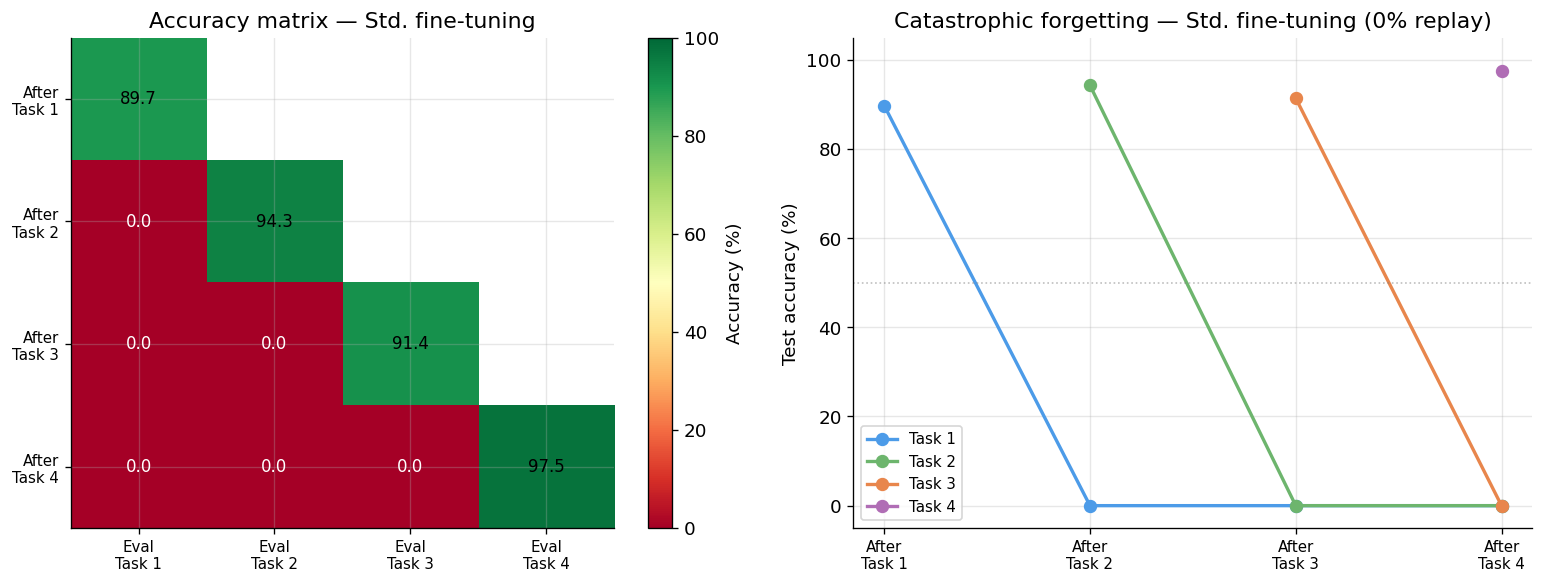

Saved: fig_catastrophic_forgetting.png

── Forgetting summary ──
  Task 1: 89.7% → 0.0%  (forgetting = 89.7pp)
  Task 2: 94.3% → 0.0%  (forgetting = 94.3pp)
  Task 3: 91.4% → 0.0%  (forgetting = 91.4pp)


In [71]:
task_colors = ['#4C9BE8', '#6DB56D', '#E8864C', '#B06DB5']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: accuracy matrix heatmap ────────────────────────────────────────────
ax = axes[0]
masked = np.ma.masked_invalid(acc_matrix * 100)
im = ax.imshow(masked, cmap='RdYlGn', vmin=0, vmax=100, aspect='auto')
plt.colorbar(im, ax=ax, label='Accuracy (%)')
ax.set_xticks(range(n_tasks))
ax.set_yticks(range(n_tasks))
ax.set_xticklabels([f'Eval\n{t}' for t in task_names], fontsize=9)
ax.set_yticklabels([f'After\n{t}' for t in task_names], fontsize=9)
ax.set_title('Accuracy matrix — Std. fine-tuning')
# Annotate cells
for i in range(n_tasks):
    for j in range(n_tasks):
        if not np.isnan(acc_matrix[i, j]):
            ax.text(j, i, f'{acc_matrix[i,j]*100:.1f}', ha='center', va='center',
                    fontsize=10, color='black' if acc_matrix[i,j] > 0.4 else 'white')

# ── Right: accuracy per task across steps (forgetting curve) ─────────────────
ax2 = axes[1]
for task_idx, (task_name, color) in enumerate(zip(task_names, task_colors)):
    # Accuracy of this task at each step where it has been evaluated
    accs   = [acc_matrix[step, task_idx] for step in range(task_idx, n_tasks)]
    x_vals = list(range(task_idx + 1, n_tasks + 1))
    valid  = [(x, a) for x, a in zip(x_vals, accs) if not np.isnan(a)]
    if valid:
        xs, ys = zip(*valid)
        ax2.plot(xs, [y * 100 for y in ys], 'o-', color=color,
                 linewidth=2, markersize=7, label=task_name)

ax2.set_xticks(range(1, n_tasks + 1))
ax2.set_xticklabels([f'After\n{t}' for t in task_names], fontsize=9)
ax2.set_ylabel('Test accuracy (%)')
ax2.set_ylim(-5, 105)
ax2.axhline(50, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax2.legend(fontsize=9, loc='lower left')
ax2.set_title('Catastrophic forgetting — Std. fine-tuning (0% replay)')

plt.tight_layout()
plt.savefig('../Plots/fig_catastrophic_forgetting.png', bbox_inches='tight')
plt.show()
print('Saved: fig_catastrophic_forgetting.png')

# ── Summary ───────────────────────────────────────────────────────────────────
print('\n── Forgetting summary ──')
for task_idx, task_name in enumerate(task_names[:-1]):
    initial_acc = acc_matrix[task_idx, task_idx]
    final_acc   = acc_matrix[-1, task_idx]
    if not (np.isnan(initial_acc) or np.isnan(final_acc)):
        forgetting = (initial_acc - final_acc) * 100
        print(f'  {task_name}: {initial_acc*100:.1f}% → {final_acc*100:.1f}%  '
              f'(forgetting = {forgetting:.1f}pp)')

## 7. Training curves

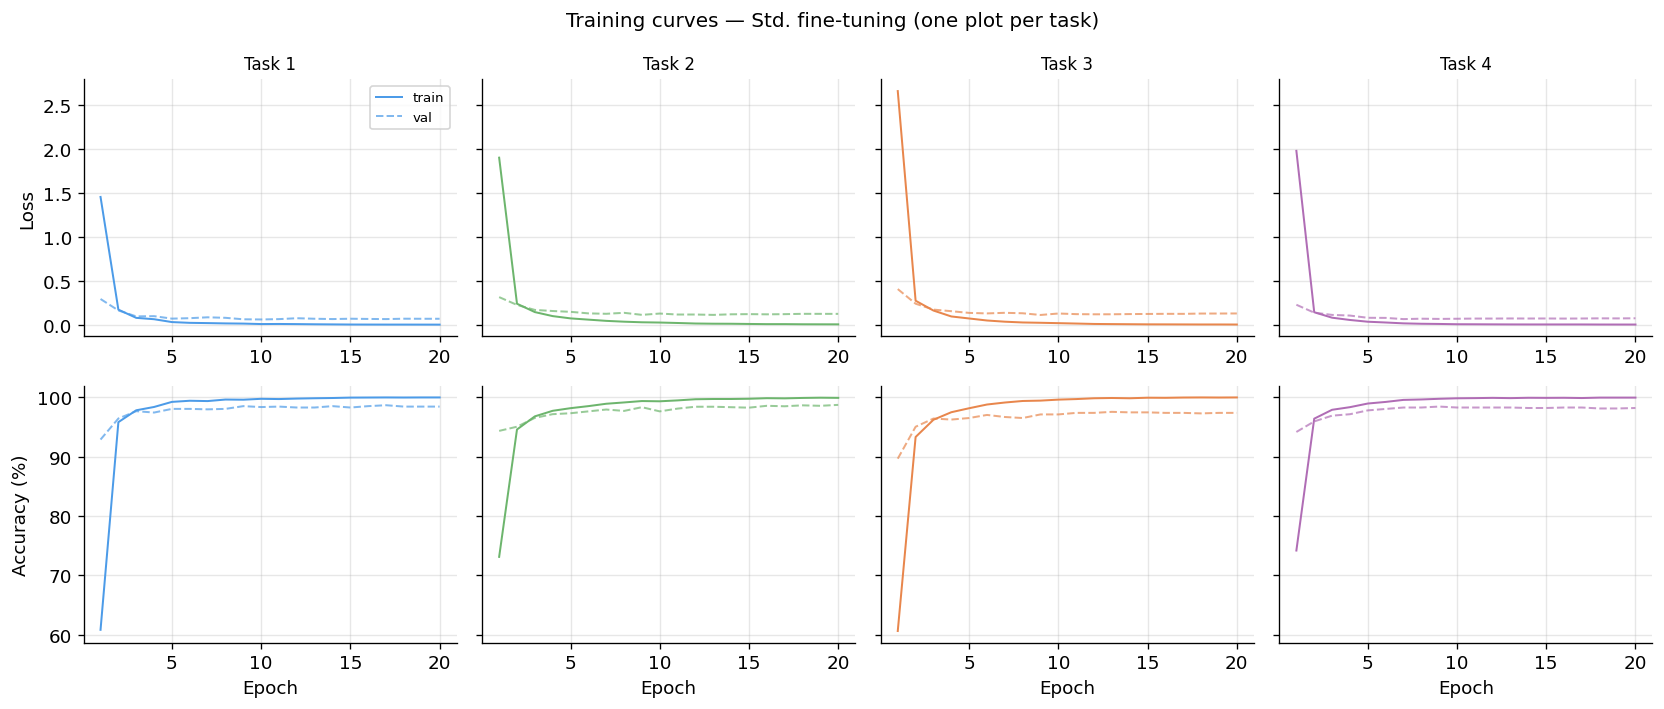

Saved: fig_training_curves.png


In [72]:
fig, axes = plt.subplots(2, n_tasks, figsize=(14, 6), sharey='row')

for col, (task_name, color) in enumerate(zip(task_names, task_colors)):
    hist = all_history[task_name]
    epochs_x = range(1, len(hist['train_loss']) + 1)

    # Loss
    axes[0, col].plot(epochs_x, hist['train_loss'], color=color, linewidth=1.2, label='train')
    axes[0, col].plot(epochs_x, hist['val_loss'],   color=color, linewidth=1.2,
                      linestyle='--', alpha=0.7, label='val')
    axes[0, col].set_title(task_name, fontsize=10)
    if col == 0:
        axes[0, col].set_ylabel('Loss')
        axes[0, col].legend(fontsize=8)

    # Accuracy
    axes[1, col].plot(epochs_x, [a*100 for a in hist['train_acc']],
                      color=color, linewidth=1.2)
    axes[1, col].plot(epochs_x, [a*100 for a in hist['val_acc']],
                      color=color, linewidth=1.2, linestyle='--', alpha=0.7)
    if col == 0:
        axes[1, col].set_ylabel('Accuracy (%)')
    axes[1, col].set_xlabel('Epoch')

fig.suptitle('Training curves — Std. fine-tuning (one plot per task)', fontsize=12)
plt.tight_layout()
plt.savefig('../Plots/fig_training_curves.png', bbox_inches='tight')
plt.show()
print('Saved: fig_training_curves.png')

## 8. Save model checkpoint

Save the final model state after all 4 tasks — used as the starting point for Phase 3 comparisons.

In [73]:
checkpoint = {
    'model_state_dict': model_std.state_dict(),
    'acc_matrix':       acc_matrix,
    'history':          all_history,
    'config': {
        'n_channels':    N_CHANNELS,
        'n_classes':     N_CLASSES_TOTAL,
        'epochs':        EPOCHS,
        'lr_init':       LR_INIT,
        'lr_decay':      LR_DECAY,
        'task_splits':   TASK_SPLITS,
    },
}
torch.save(checkpoint, 'checkpoint_std.pt')
print('Saved: checkpoint_std.pt')

Saved: checkpoint_std.pt


## 9. Summary and next steps

### What we built

| Component | Detail |
|---|---|
| `GaitCNN` | 4× Conv1D → ReLU → MaxPool, FC embedding (128-dim), FC classifier |
| `embed()` method | Exposes the 128-dim feature vector `h` — hook point for CDML in Phase 3 |
| Sequential training | Tasks 1→4 with exponential LR decay, matching paper's setup |
| `acc_matrix` | Full accuracy matrix: rows = training steps, cols = evaluated tasks |
| Forgetting curve | Reproduces Fig. 4 `Std.` baseline from the paper |

### Interpreting the forgetting curve

- **Diagonal** of the accuracy matrix = accuracy right after learning a task (best case)
- **Last row** = accuracy of all tasks after final training step (worst case for early tasks)
- **Gap** between diagonal and last row = catastrophic forgetting magnitude

### Next steps — Phase 3

- [ ] Implement **FiLM / Adapt layer** (γₖ, βₖ per task — feature-wise linear modulation)
- [ ] Implement **CDML layer** (`m = sₖ ⊙ h`, pseudo-random binary sequence per task)
- [ ] Re-run the 4-task sequential training with each method
- [ ] Compare accuracy matrices → reproduce Table III and Fig. 4 of the paper
- [ ] Add optional **replay** (10%, 30%) to reproduce ablation study

---
*Notebook: phase2_continual_learning.ipynb*